# ML: Predicting dJ/dV Curve Parameters from Composition

**Features:** Pt, Pd, Au, Ir (atomic fractions)  
**Targets:** the six fitted dJ/dV model parameters (k, V0, u1, s1, A1, A2) from `dJdVpreprocess.ipynb`

**Workflow**
1. Load and clean `composition_djdV.csv`.
2. Screen six multi-output regressors with repeated cross-validation (targets standardized so k does not dominate A2).
3. Re-rank the candidates in *curve space*: reconstruct dJ/dV from true and predicted parameters and compare the curves, since parameters trade off inside the model.
4. Report per-parameter test metrics for the selected model.
5. True-vs-predicted curve gallery and agreement distribution.
6. Quaternary-simplex maps of each predicted parameter.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from sklearn.model_selection import (
    train_test_split,
    RepeatedKFold,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    WhiteKernel,
    ConstantKernel,
)
from sklearn.metrics import (
    root_mean_squared_error,
    r2_score,
    mean_absolute_error,
)

from djdv_model import djdv_model

import warnings

warnings.filterwarnings('ignore')
from sklearn.exceptions import ConvergenceWarning

SEED = 42
X_COLS = ['Pt', 'Pd', 'Au', 'Ir']
Y_COLS = ['k', 'V0', 'u1', 's1', 'A1', 'A2']

# The dJ/dV fits in dJdVpreprocess.ipynb are performed on this window;
# curve-space evaluation below uses the same range.
V_FIT_MIN, V_FIT_MAX = 1.05, 1.90

## 1. Load

In [2]:
df = pd.read_csv('data/composition_djdV.csv')

print('Target summary statistics:')
print(df[Y_COLS].describe().T[['min', 'mean', 'std', '50%', 'max']])
print()
print('Skewness:')
print(df[Y_COLS].skew(numeric_only=True))

Target summary statistics:
          min       mean       std        50%        max
k   10.148710  16.029838  4.705225  15.018152  56.969367
V0   1.509945   1.672462  0.053721   1.673069   1.767365
u1   1.206464   1.436931  0.117538   1.425630   1.600000
s1   0.055287   0.146689  0.069457   0.117032   0.300000
A1   0.008947   0.055666  0.013401   0.057322   0.094454
A2   0.001785   0.013223  0.009021   0.012604   0.040207

Skewness:
k     4.472205
V0   -0.971868
u1   -0.125132
s1    0.998187
A1   -0.374640
A2    0.492115
dtype: float64


## 2. Clean & Split

In [3]:
df = (
    df[X_COLS + Y_COLS]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=False)
    .rename(columns={'index': 'sample_id'})
)

X = df[X_COLS].to_numpy(float)
Y = df[Y_COLS].to_numpy(float)
ids = df['sample_id'].to_numpy()

X_train, X_test, Y_train, Y_test, id_train, id_test = train_test_split(
    X, Y, ids, test_size=0.30, random_state=SEED, shuffle=True
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

Train: 116  |  Test: 50


## 3. Model Screen — Parameter Space

Six candidates, each wrapped in `TransformedTargetRegressor` with a `StandardScaler` on the targets. `CV R2` is the uniform average over the six standardized parameters under 5×3 `RepeatedKFold`; the `Overfit gap` (train R² − CV R²) flags variance.

In [4]:
class QuietGaussianProcessRegressor(GaussianProcessRegressor):
    """GP that silences the length-scale upper-bound ConvergenceWarning.

    The filter is set inside ``fit``, so it takes effect in each loky
    worker process. A ``catch_warnings`` block around ``cross_validate``
    would not, since the parent's filters do not propagate to the
    worker processes spawned by ``n_jobs=-1``. Scoped to the specific
    message, so Ridge/tree convergence warnings stay live. A railed
    length scale is a real result here (a composition dimension the
    RBF wants to flatten, expected from the simplex redundancy of four
    fractions summing to one), which is why it is safe to quiet.
    """

    def fit(self, X, y):
        with warnings.catch_warnings():
            warnings.filterwarnings(
                'ignore',
                message='The optimal value found for dimension',
                category=ConvergenceWarning,
            )
            return super().fit(X, y)

def target_scaled(estimator):
    """Standardize the six targets so no single parameter dominates.

    k (~10-60) would otherwise swamp A2 (~0.01) in any squared-error
    objective; predictions are inverse-transformed back to real units.
    """
    return TransformedTargetRegressor(
        regressor=estimator, transformer=StandardScaler()
    )


gp_kernel = ConstantKernel(1.0) * RBF([0.2] * 4) + WhiteKernel(0.1)

candidates = {
    'Ridge': target_scaled(
        Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))])
    ),
    'KNN (k=12, distance)': target_scaled(
        Pipeline(
            [
                ('sc', StandardScaler()),
                ('m', KNeighborsRegressor(12, weights='distance')),
            ]
        )
    ),
    'Random Forest': target_scaled(
        RandomForestRegressor(n_estimators=400, random_state=SEED, n_jobs=-1)
    ),
    'Extra Trees': target_scaled(
        ExtraTreesRegressor(n_estimators=400, random_state=SEED, n_jobs=-1)
    ),
    'Hist GB (per-target)': target_scaled(
        MultiOutputRegressor(HistGradientBoostingRegressor(random_state=SEED))
    ),
    'Gaussian Process (RBF)': target_scaled(
        Pipeline(
            [
                ('sc', StandardScaler()),
                (
                    'm',
                    QuietGaussianProcessRegressor(
                        kernel=gp_kernel,
                        alpha=1e-6,
                        n_restarts_optimizer=3,
                        random_state=SEED,
                    )
                ),
            ]
        )
    ),
}

cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEED)

rows = []
for name, model in candidates.items():
    cvres = cross_validate(
        model,
        X_train,
        Y_train,
        cv=cv,
        scoring='r2',
        return_train_score=True,
        n_jobs=-1,
    )
    rows.append(
        {
            'Model': name,
            'CV R2': cvres['test_score'].mean(),
            'CV R2 std': cvres['test_score'].std(),
            'Train R2': cvres['train_score'].mean(),
        }
    )

screen = pd.DataFrame(rows)
screen['Overfit gap'] = screen['Train R2'] - screen['CV R2']
screen = screen.sort_values('CV R2', ascending=False).reset_index(drop=True)
print(screen.round(4).to_string(index=False))

                 Model  CV R2  CV R2 std  Train R2  Overfit gap
  KNN (k=12, distance) 0.2669     0.1138    1.0000       0.7331
  Hist GB (per-target) 0.1977     0.1399    0.6491       0.4514
                 Ridge 0.1520     0.1080    0.2762       0.1242
           Extra Trees 0.1513     0.1650    1.0000       0.8487
Gaussian Process (RBF) 0.1424     0.1289    0.9237       0.7813
         Random Forest 0.1401     0.1500    0.8893       0.7492


## 4. Model Selection — Curve Space

The quantity of interest is the reconstructed dJ/dV curve, not the raw parameters: A1 and s1 (amplitude and width) partially compensate each other inside the model, so a model with mediocre per-parameter R² can still reconstruct curves well. Each candidate is refit on the training set and scored on the held-out set by comparing `djdv_model(V, p_true)` against `djdv_model(V, p_pred)` over the fit window.

In [5]:
# Parameter-space R2 is a proxy. What matters is whether the composition
# -> parameters -> curve chain reproduces the measured dJ/dV shape, and
# parameters trade off inside the model (an error in A1 can be absorbed by
# s1), so models are compared on reconstructed curves directly.
V_GRID = np.linspace(V_FIT_MIN, V_FIT_MAX, 300)


def curve_metrics(Y_true, Y_pred):
    """Per-sample R2 and relative RMSE between reconstructed curves."""
    r2s, rel = [], []
    for p_true, p_pred in zip(Y_true, Y_pred):
        c_true = djdv_model(V_GRID, p_true)
        c_pred = djdv_model(V_GRID, p_pred)
        ss_res = np.sum((c_pred - c_true) ** 2)
        ss_tot = np.sum((c_true - c_true.mean()) ** 2)
        r2s.append(1.0 - ss_res / ss_tot)
        rel.append(np.sqrt(((c_pred - c_true) ** 2).mean()) / c_true.max())
    return np.array(r2s), np.array(rel)


rows = []
fitted = {}
for name, model in candidates.items():
    model.fit(X_train, Y_train)
    fitted[name] = model
    r2s, rel = curve_metrics(Y_test, model.predict(X_test))
    rows.append(
        {
            'Model': name,
            'Curve R2 (median)': np.median(r2s),
            'Curve R2 > 0.8': (r2s > 0.8).mean(),
            'Rel. RMSE (median %)': 100 * np.median(rel),
        }
    )

curve_screen = (
    pd.DataFrame(rows)
    .sort_values('Curve R2 (median)', ascending=False)
    .reset_index(drop=True)
)
print(curve_screen.round(3).to_string(index=False))

best_name = curve_screen.iloc[0]['Model']
best_model = fitted[best_name]
print(f'\nSelected model: {best_name}')

                 Model  Curve R2 (median)  Curve R2 > 0.8  Rel. RMSE (median %)
                 Ridge              0.946            0.80                 7.400
         Random Forest              0.943            0.74                 7.725
           Extra Trees              0.943            0.72                 7.790
  Hist GB (per-target)              0.939            0.74                 7.651
  KNN (k=12, distance)              0.932            0.80                 8.669
Gaussian Process (RBF)              0.910            0.70                 9.659

Selected model: Ridge


## 5. Held-out Test Metrics — Selected Model

In [6]:
Y_pred = best_model.predict(X_test)

rows = []
for j, col in enumerate(Y_COLS):
    rows.append(
        {
            'Parameter': col,
            'R2': r2_score(Y_test[:, j], Y_pred[:, j]),
            'RMSE': root_mean_squared_error(Y_test[:, j], Y_pred[:, j]),
            'MAE': mean_absolute_error(Y_test[:, j], Y_pred[:, j]),
        }
    )
per_target = pd.DataFrame(rows)
print('=== Held-out test set, per parameter ===')
print(per_target.round(4).to_string(index=False))
print(
    f"\nUniform-average R2: "
    f"{r2_score(Y_test, Y_pred, multioutput='uniform_average'):.4f}"
)

# Assemble a results frame for downstream plotting
X_test_df = pd.DataFrame(X_test, columns=X_COLS)
Y_test_df = pd.DataFrame(Y_test, columns=Y_COLS)
Y_pred_df = pd.DataFrame(Y_pred, columns=[f'{c}_pred' for c in Y_COLS])
results_df = pd.concat([X_test_df, Y_test_df, Y_pred_df], axis=1)
results_df['sample_id'] = id_test

=== Held-out test set, per parameter ===
Parameter      R2   RMSE    MAE
        k -0.4171 3.6519 3.1254
       V0  0.5319 0.0389 0.0281
       u1 -0.1329 0.1138 0.0917
       s1  0.1134 0.0670 0.0532
       A1  0.0492 0.0130 0.0103
       A2  0.6877 0.0045 0.0036

Uniform-average R2: 0.1387


## 6. True vs Predicted dJ/dV Curves

Curve-space agreement on the test set:
  median curve R2:  0.946
  curves with R2 > 0.8: 40/50
  median relative RMSE: 7.4%


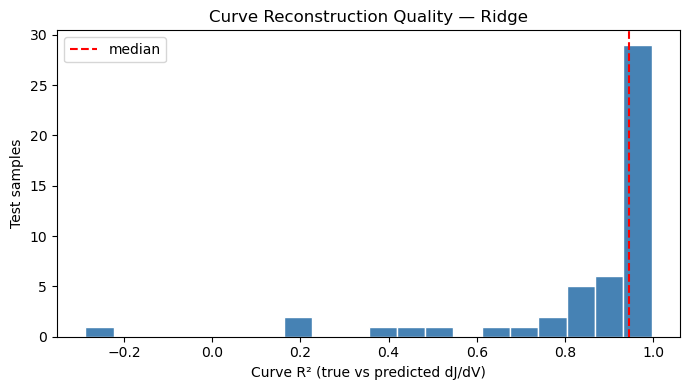

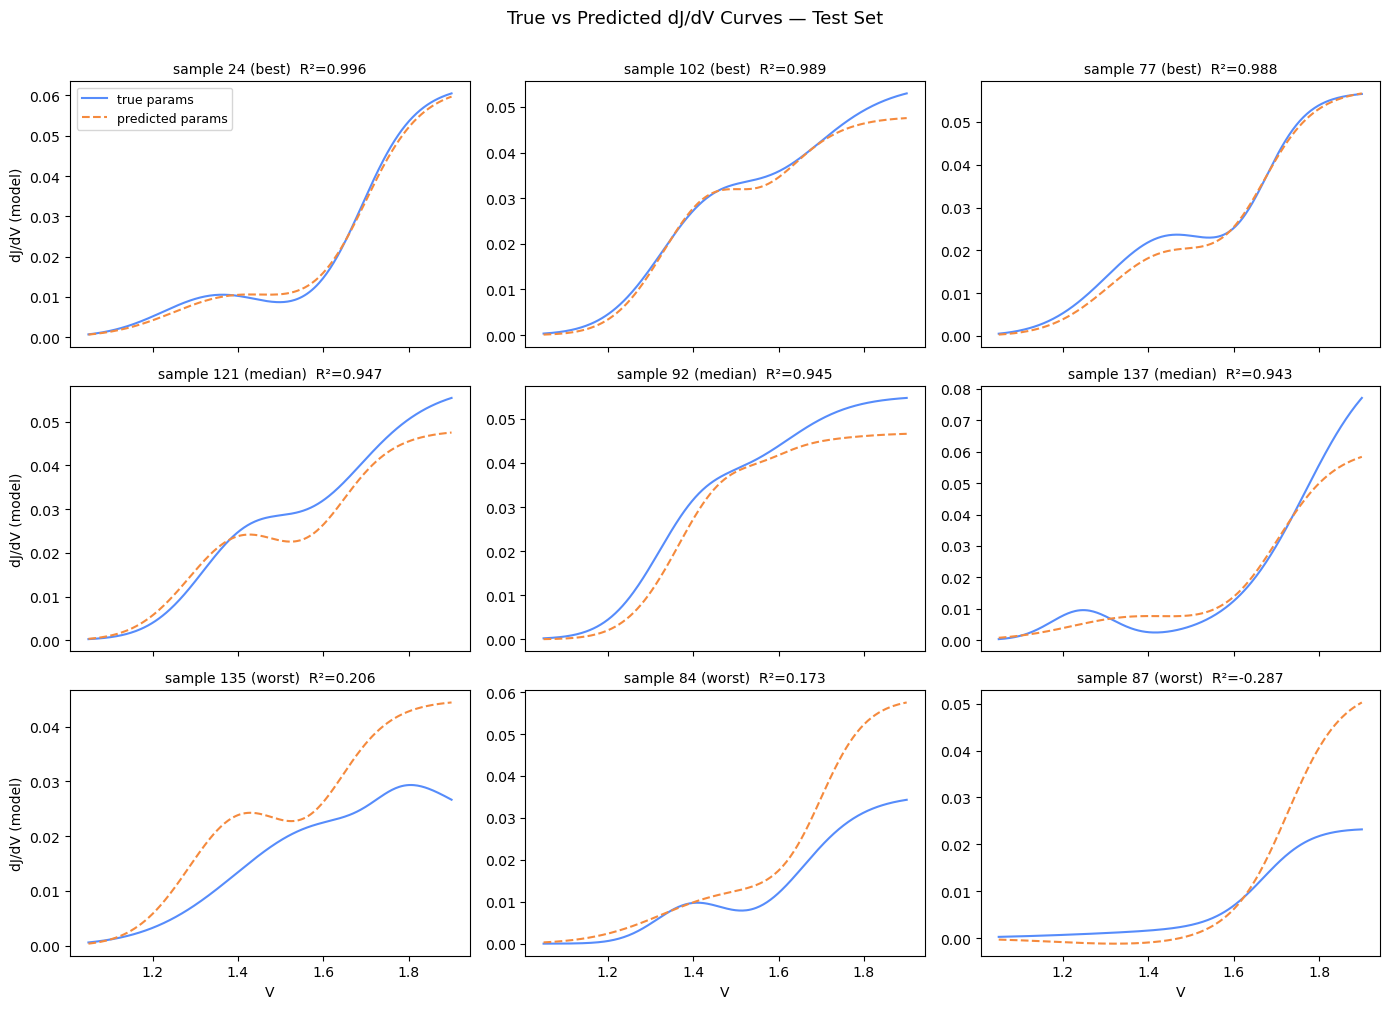

In [7]:
TRUE_COLS = Y_COLS
PRED_COLS = [f'{c}_pred' for c in Y_COLS]

curve_r2s, curve_rel = curve_metrics(
    results_df[TRUE_COLS].to_numpy(float),
    results_df[PRED_COLS].to_numpy(float),
)
results_df['curve_r2'] = curve_r2s

print('Curve-space agreement on the test set:')
print(f'  median curve R2:  {np.median(curve_r2s):.3f}')
print(f'  curves with R2 > 0.8: {(curve_r2s > 0.8).sum()}/{len(curve_r2s)}')
print(f'  median relative RMSE: {100 * np.median(curve_rel):.1f}%')

# Distribution of curve-level agreement
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(curve_r2s, bins=20, color='steelblue', edgecolor='white')
ax.axvline(np.median(curve_r2s), color='red', linestyle='--', label='median')
ax.set_xlabel('Curve R² (true vs predicted dJ/dV)')
ax.set_ylabel('Test samples')
ax.set_title(f'Curve Reconstruction Quality — {best_name}')
ax.legend()
plt.tight_layout()
plt.savefig('images/djdv_curve_r2_hist.png', dpi=300, bbox_inches='tight')
plt.show()

# Gallery: 3 best, 3 median, 3 worst reconstructions
order = np.argsort(curve_r2s)[::-1]
mid = len(order) // 2
picks = list(order[:3]) + list(order[mid - 1:mid + 2]) + list(order[-3:])
labels = ['best'] * 3 + ['median'] * 3 + ['worst'] * 3

fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True)
for ax, idx, lab in zip(axes.ravel(), picks, labels):
    row = results_df.iloc[idx]
    p_true = row[TRUE_COLS].to_numpy(float)
    p_pred = row[PRED_COLS].to_numpy(float)
    ax.plot(V_GRID, djdv_model(V_GRID, p_true), label='true params')
    ax.plot(V_GRID, djdv_model(V_GRID, p_pred), '--', label='predicted params')
    ax.set_title(
        f"sample {int(row['sample_id'])} ({lab})  "
        f"R²={row['curve_r2']:.3f}",
        fontsize=10,
    )
for ax in axes[-1]:
    ax.set_xlabel('V')
for ax in axes[:, 0]:
    ax.set_ylabel('dJ/dV (model)')
axes[0, 0].legend(fontsize=9)
fig.suptitle('True vs Predicted dJ/dV Curves — Test Set', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig('images/djdv_true_vs_pred_grid.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Quaternary Simplex Maps

Each fitted parameter predicted across the full quaternary composition simplex; useful for reading off where in composition space the OER onset (V0), steepness (k), and hump features (u1, s1, A1, A2) are optimized.

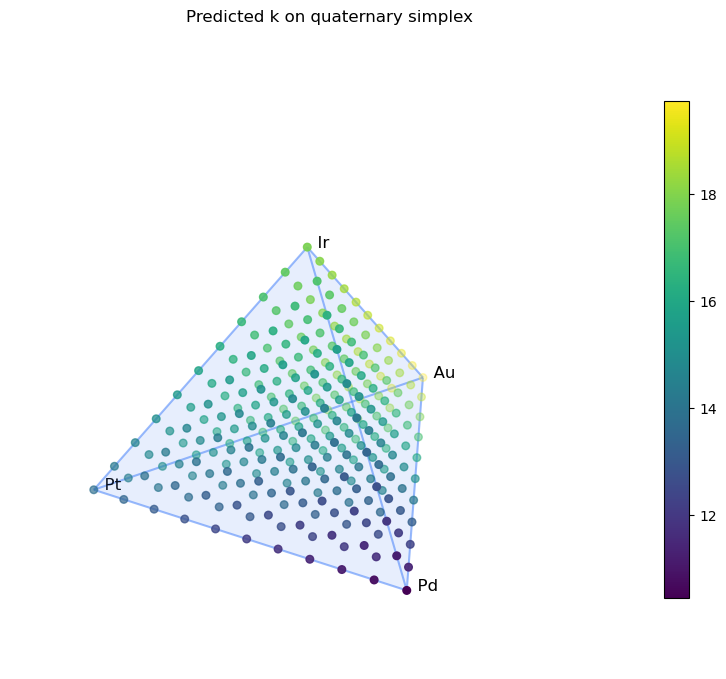

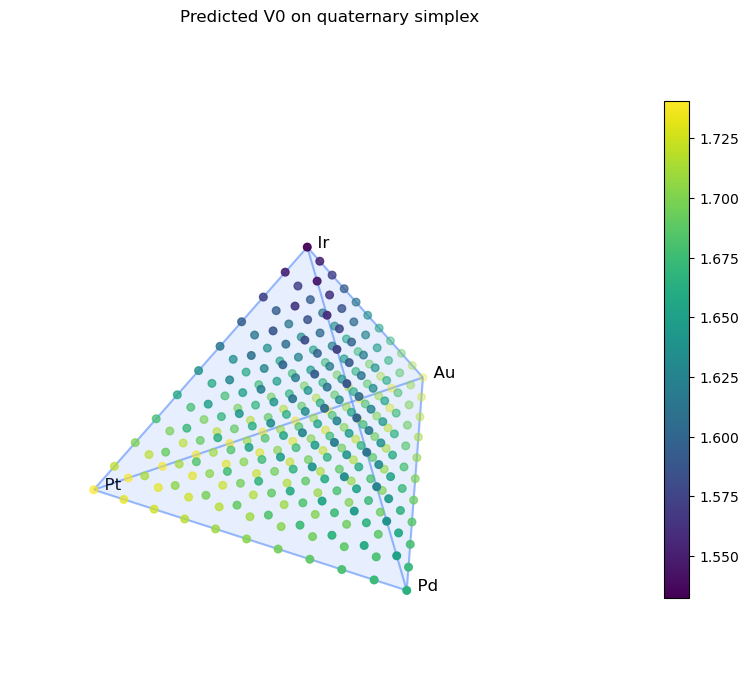

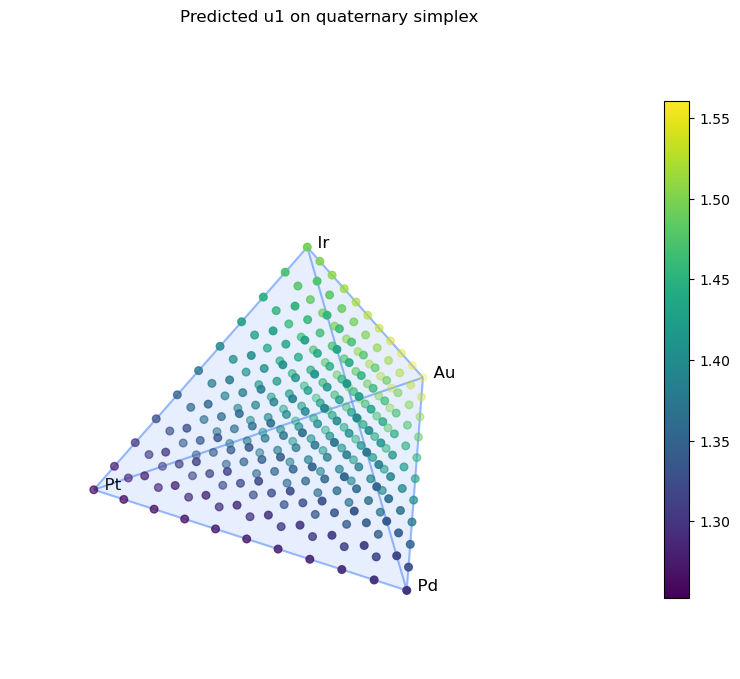

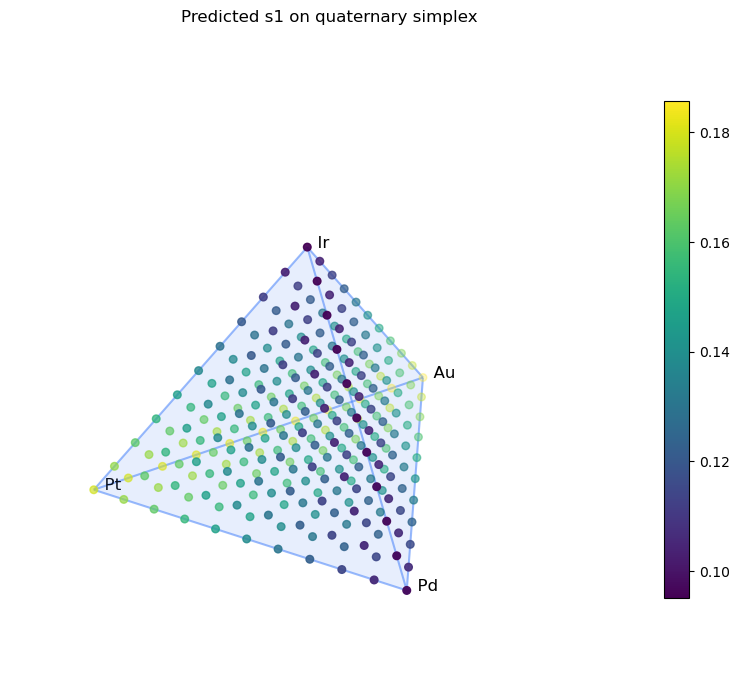

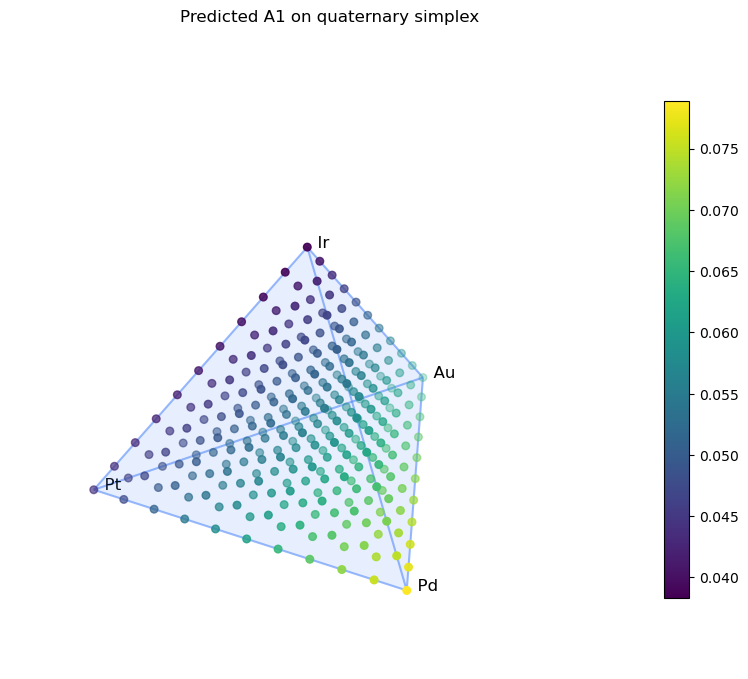

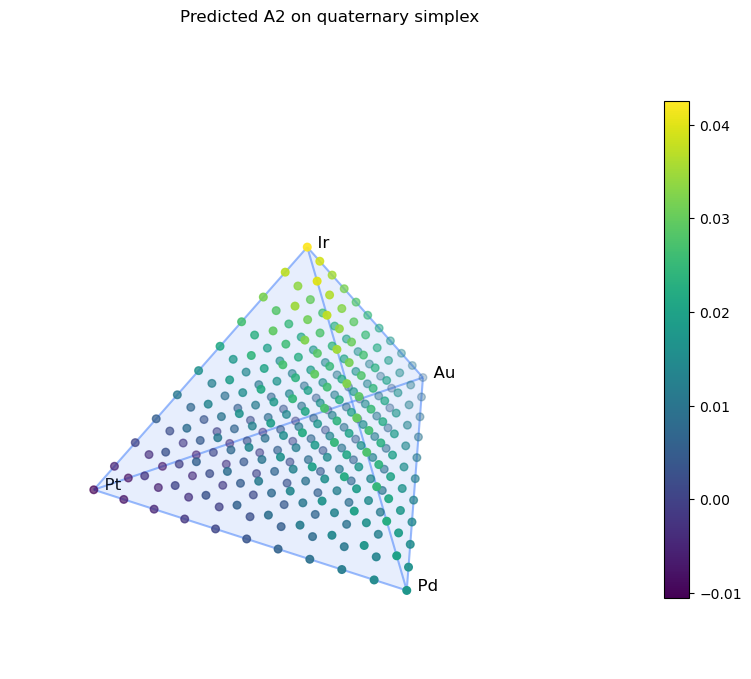

In [8]:
# ── Tetrahedron vertices (Pt, Pd, Au, Ir) ────────────────────
sqrt3 = np.sqrt(3.0)
VERTICES = np.array(
    [
        [0.0, 0.0, 0.0],  # Pt
        [1.0, 0.0, 0.0],  # Pd
        [0.5, sqrt3 / 2, 0.0],  # Au
        [0.5, sqrt3 / 6, np.sqrt(2.0 / 3.0)],  # Ir
    ]
)


def simplex_lattice(step=0.1):
    """All 4-tuples on the quaternary simplex at the given step size."""
    n = int(round(1.0 / step))
    comps = []
    for a in range(n + 1):
        for b in range(n + 1 - a):
            for c in range(n + 1 - a - b):
                d = n - a - b - c
                comps.append([a, b, c, d])
    return np.array(comps, dtype=float) / n


def barycentric_to_cartesian(comps):
    """Map (N, 4) barycentric coordinates to (N, 3) Cartesian."""
    return comps @ VERTICES


comps = simplex_lattice(step=0.1)
xyz = barycentric_to_cartesian(comps)


def plot_quaternary_tetra(xyz, values, title, ax=None, cmap='viridis', s=30):
    from mpl_toolkits.mplot3d.art3d import (
        Poly3DCollection,
        Line3DCollection,
    )

    if ax is None:
        fig = plt.figure(figsize=(8, 7))
        ax = fig.add_subplot(111, projection='3d')

    Vp, Vpd, Vau, Vir = VERTICES

    edges = [
        (Vp, Vpd),
        (Vp, Vau),
        (Vp, Vir),
        (Vpd, Vau),
        (Vpd, Vir),
        (Vau, Vir),
    ]
    ax.add_collection3d(Line3DCollection(edges, linewidths=1.5, alpha=0.6))

    faces = [
        [Vp, Vpd, Vau],
        [Vp, Vpd, Vir],
        [Vp, Vau, Vir],
        [Vpd, Vau, Vir],
    ]
    ax.add_collection3d(Poly3DCollection(faces, alpha=0.07))

    norm = Normalize(vmin=np.nanmin(values), vmax=np.nanmax(values))
    ax.scatter(
        xyz[:, 0],
        xyz[:, 1],
        xyz[:, 2],
        c=values,
        cmap=cmap,
        norm=norm,
        s=s,
        depthshade=True,
    )

    for label, vert in zip(['Pt', 'Pd', 'Au', 'Ir'], VERTICES):
        ax.text(vert[0], vert[1], vert[2], f'  {label}', fontsize=12)

    ax.set_axis_off()
    ax.set_title(title)
    plt.colorbar(
        ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.75, pad=0.02
    )
    return ax


# ── Predict on the simplex lattice ──
X_lattice = pd.DataFrame(comps, columns=X_COLS)
Y_lattice = best_model.predict(X_lattice.values)

for j, param_name in enumerate(Y_COLS):
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')
    plot_quaternary_tetra(
        xyz,
        Y_lattice[:, j],
        title=f'Predicted {param_name} on quaternary simplex',
        ax=ax,
    )
    plt.tight_layout()
    plt.savefig(
        f'images/quaternary_{param_name}.pdf',
        format='pdf',
        bbox_inches='tight',
    )
    plt.show()